# Part A: Pokemon Stat & Type Analysis


**Context:** Imagine you are a Pokémon data analyst working to understand how base stats and elemental types influence overall power. As an analyst, your goal is to evaluate key features, group similar Pokémon into distinct tiers, and build predictive models to estimate a Pokémon's performance potential. 

The data includes:
- **Name** - The name of each Pokémon.
- **Type1** - The primary elemental type (e.g. Fire, Water, Grass).
- **HP** - Base Health Points (defensive survivability metric).
- **Attack** - Attack: Base physical attack power.
- **Defense** - Base physical damage resistance.
- **Speed** - Speed metric determining turn order.
- **Total** 

## 1) Import the data.

### 1.1) Load the dataset.

In [26]:
#a) 
import pandas as pd

pokemon_df = pd.read_csv(
    r"C:\Users\tiwa1\Downloads\archive (1)\PokemonData.csv"
)

# Display the first few rows to verify it loaded
pokemon_df.head()

,Num,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [27]:
pokemon_df.shape

(800, 12)

In [28]:
pokemon_df.dtypes

Num            int64
Name          object
Type1         object
Type2         object
HP             int64
Attack         int64
Defense        int64
SpAtk          int64
SpDef          int64
Speed          int64
Generation     int64
Legendary       bool
dtype: object

In [29]:
pokemon_df.describe()

,Num,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


## 2) Clean the data.

### 2.1) Remove the duplicate rows (if exist).


In [30]:
pokemon_df = pokemon_df.drop_duplicates()

In [31]:
pokemon_df.shape

(800, 12)

### 2.2) Handle missing values (if exist).

In [32]:
pokemon_df.isna().sum()

# Finding the mode(most common value) for the Type2 column 
type2_mode = pokemon_df["Type2"].mode()[0]
pokemon_df["Type2"] = pokemon_df["Type2"].fillna(type2_mode) 

pokemon_df.isna().sum()

Num           0
Name          0
Type1         0
Type2         0
HP            0
Attack        0
Defense       0
SpAtk         0
SpDef         0
Speed         0
Generation    0
Legendary     0
dtype: int64

2.1

### 2.3) Handle extreme values (if exist).

In [33]:
# Define numerical Pokémon stat columns
numeric_cols = ["HP", "Attack", "Defense", "Speed", "SpAtk","SpDef"] 

# Looping through each stat to find and drop extreme outliers
for col in numeric_cols: 
    Q1 = pokemon_df[col].quantile(0.25) 
    Q3 = pokemon_df[col].quantile(0.75) 
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find how many outliers exist in this column
    outliers = pokemon_df[(pokemon_df[col] < lower_bound) | (pokemon_df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers") 

    # Keeping rows that fall within the normal bounds
    pokemon_df = pokemon_df[(pokemon_df[col] >= lower_bound) & (pokemon_df[col] <= upper_bound)]

# Output the dataset's shape again to see how many extreme Pokémon were dropped
pokemon_df.shape
    

HP: 19 outliers
Attack: 7 outliers
Defense: 12 outliers
Speed: 2 outliers
SpAtk: 8 outliers
SpDef: 13 outliers


(739, 12)

## 3) Perform deeper exploratory data analysis (EDA).

### 3.1) Univariate Analysis.

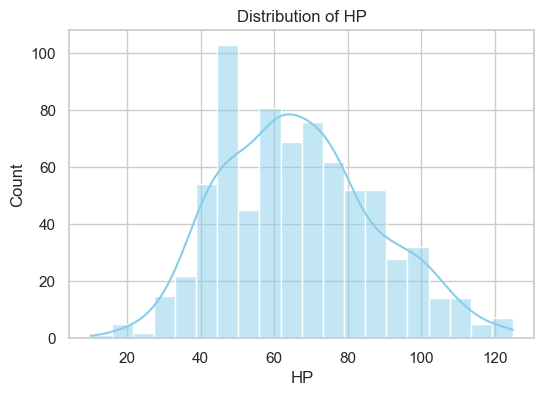

<Figure size 640x480 with 0 Axes>

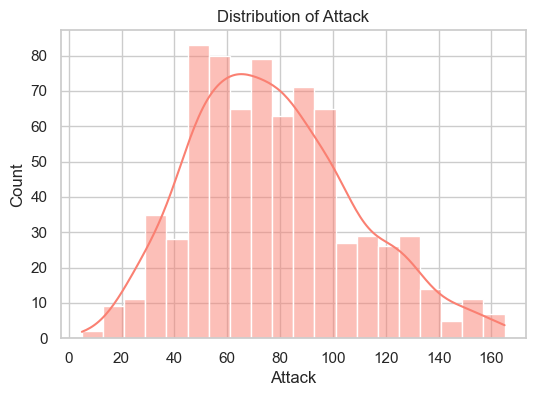

C:\Users\tiwa1\AppData\Local\Temp\ipykernel_11540\1407360782.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=pokemon_df["Type1"], order=pokemon_df["Type1"].value_counts().index, palette="viridis")


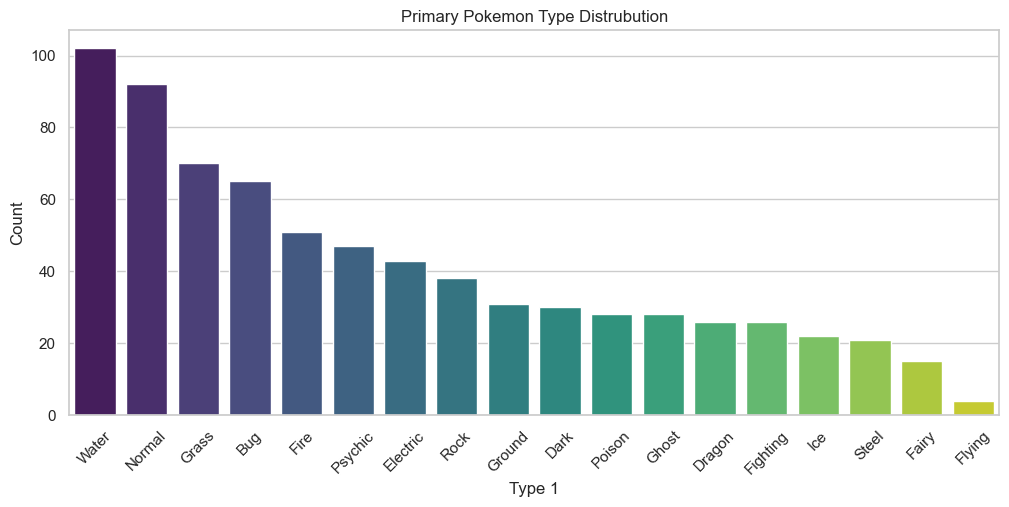

In [34]:
import matplotlib.pyplot as plt 
import seaborn as sns 

# Setting a clean plot background style 
sns.set(style="whitegrid") 

# 1. Histogram - HP 
plt.figure(figsize=(6,4)) 
sns.histplot(pokemon_df["HP"], kde=True, bins=20, color="skyblue") 
plt.title("Distribution of HP") 
plt.xlabel("HP") 
plt.ylabel("Count") 
plt.show()

# 2. Histogram - Attack
plt.clf()
plt.figure(figsize=(6,4)) 
sns.histplot(pokemon_df["Attack"], kde=True, bins=20, color="salmon") 
plt.title("Distribution of Attack") 
plt.xlabel("Attack") 
plt.ylabel("Count") 
plt.show()

# 3. Countplot - Type1 (Primary Pokémon Elements)
plt.figure(figsize=(12,5)) 
sns.countplot(x=pokemon_df["Type1"], order=pokemon_df["Type1"].value_counts().index, palette="viridis")
plt.title("Primary Pokemon Type Distrubution") 
plt.xlabel("Type 1") 
plt.ylabel("Count") 
plt.xticks(rotation=45)
plt.show()

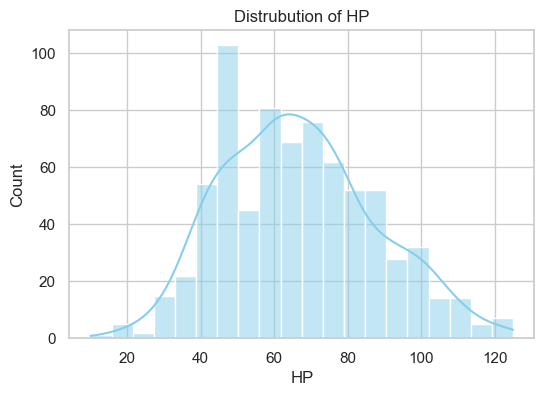

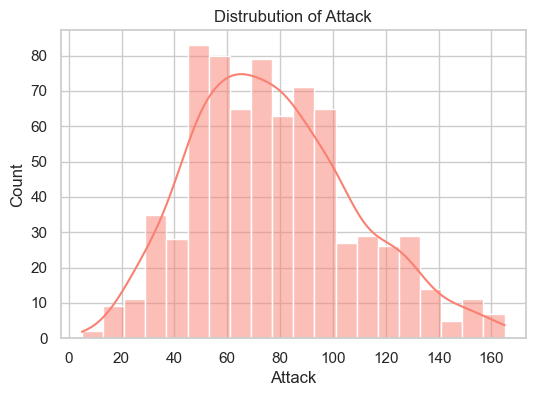

In [69]:
import matplotlib.pyplot as plt 
import seaborn as sns 

# Set a clean plot background style 
sns.set(style="whitegrid") 

# 1. Histogram - HP 
plt.figure(figsize=(6,4)) 
sns.histplot(pokemon_df["HP"], kde=True, bins=20, color="skyblue")
plt.title("Distrubution of HP")
plt.xlabel("HP") 
plt.ylabel("Count") 
plt.show()

#2. Histogram - Attack 
plt.figure(figsize=(6,4)) 
sns.histplot(pokemon_df["Attack"], kde=True, bins=20, color="salmon")
plt.title("Distrubution of Attack")
plt.xlabel("Attack") 
plt.ylabel("Count") 
plt.show()



### 3.2) Bivariate Analysis.

<Figure size 640x480 with 0 Axes>

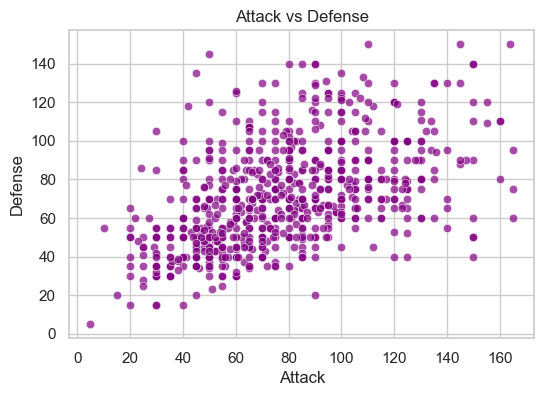

C:\Users\tiwa1\AppData\Local\Temp\ipykernel_11540\1175736368.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=pokemon_df["Type1"], y=pokemon_df["Speed"], palette="plasma")


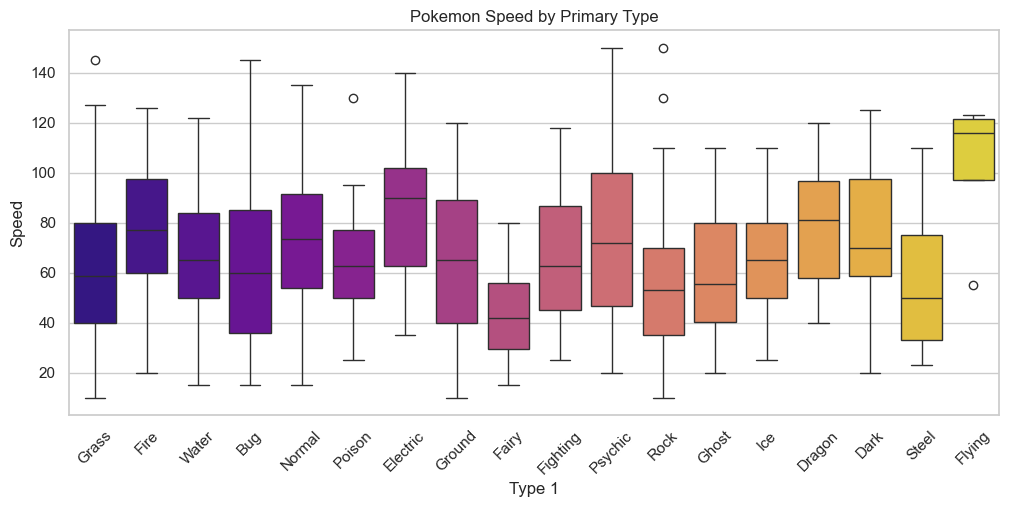

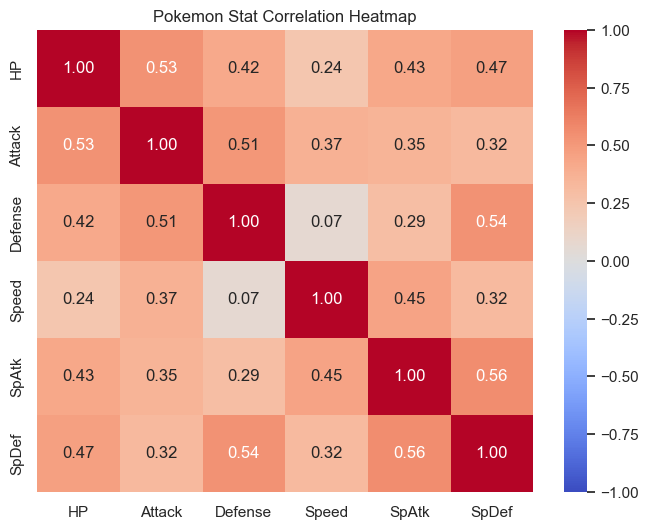

In [70]:
# import matplotlib.pyplot as plt 
import seaborn as sns 

plt.clf() 
sns.set(style="whitegrid") 

# 1. Scatter Plot - Attack vs Defense
plt.figure(figsize=(6,4))
sns.scatterplot(x=pokemon_df["Attack"], y=pokemon_df["Defense"], color="purple",alpha=0.7)
plt.title("Attack vs Defense") 
plt.xlabel("Attack") 
plt.ylabel("Defense") 
plt.show() 

# 2. Box Plot - Speed by Type 1
plt.figure(figsize=(12,5))
sns.boxplot(x=pokemon_df["Type1"], y=pokemon_df["Speed"], palette="plasma")
plt.title("Pokemon Speed by Primary Type") 
plt.xlabel("Type 1") 
plt.ylabel("Speed") 
plt.xticks(rotation=45)
plt.show() 

# 3. Correlation Heatmap 
plt.figure(figsize=(8,6)) 
stat_cols = ["HP", "Attack", "Defense", "Speed", "SpAtk", "SpDef"]
corr_matrix = pokemon_df[stat_cols].corr()

# Plot heatmap grid 
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Pokemon Stat Correlation Heatmap") 
plt.show()

The box plot reveals clear operational design choices in Pokemon stats across types. Flying and Electric types demonstrate consistently high median speeds, whereas Fairy and Steel types lean heavily toward slower, more defensive speed brackets. Types like Psychic and Bug exhibit the highest variation, containing both exceptionally slow and exceptionally fast species.

## 4) Perform K-Means Clustering using `Attack` and `Defense`.

C:\Users\tiwa1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\tiwa1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\tiwa1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\tiwa1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Figure size 640x480 with 0 Axes>

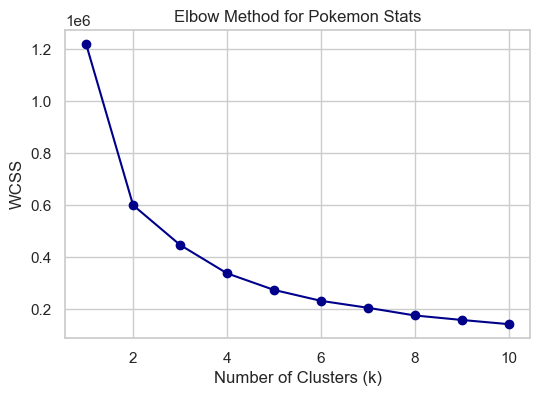

In [37]:
X = pokemon_df[["Attack", "Defense"]]
X.head()

from sklearn.cluster import KMeans

# Using Within-Cluster Sum of Squares method to see how tight our groups are
wcss = [] 

# Loop 10 times to test out splitting Pokémon into 1 group, 2 groups, 3 groups... up to 10 groups
for k in range(1,11): 
    model = KMeans(n_clusters=k, random_state=42) 
    model.fit(X) 
    wcss.append(model.inertia_)

# Erasing the chalkboard memory and plot our Elbow Method graph
plt.clf()
plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o', color="darkblue")
plt.title("Elbow Method for Pokemon Stats") 
plt.xlabel("Number of Clusters (k)") 
plt.ylabel("WCSS") 
plt.show()

"To determine the optimal number of clusters for the Pokémon dataset, the Elbow Method was conducted by testing $k$ values ranging from 1 to 10. The resulting line plot tracks the Within-Cluster Sum of Squares (WCSS) against the number of clusters.A significant, dramatic drop in WCSS occurs between $k=1$ and $k=2$, followed by a clear, continuing deceleration in the rate of decline. A distinct 'elbow joint' is visible at $k=4$, where the curve begins to flatten out significantly. Beyond 4 clusters, the law of diminishing returns applies, as adding more groups yields negligible improvements in cluster compactness. Therefore, $k=4$ is selected as the optimal number of clusters to group the Pokémon effectively without overcomplicating the model."

### 4.0) Scaling the features before performing KMeans clustering. If scaling is needed, going to  appropriate scaling to numerical features.

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans 

# 1. Grabbing raw data columns leaving the original dataframe untouched 
X_pokemon = pokemon_df[["Attack", "Defense"]] 

# 2. Initialize the scaler and fit/transform the data into seperate variable 
scaler = StandardScaler() 
X_pokemon_scaled = scaler.fit_transform(X_pokemon) 

# 3. Use the SCALED features to fit the KMeans model (k=4) 
kmeans_pokemon = KMeans(n_clusters=4, random_state=42)

# 4. Save the cluster labels back into the ORIGINAL dataframe for visualization
pokemon_df["Cluster"] = kmeans_pokemon.fit_predict(X_pokemon_scaled)

# Let's take a quick peek to make sure it worked
pokemon_df[["Name", "Attack", "Defense","Cluster"]].head()


C:\Users\tiwa1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


,Name,Attack,Defense,Cluster
0,Bulbasaur,49,49,1
1,Ivysaur,62,63,1
2,Venusaur,82,83,2
3,VenusaurMega Venusaur,100,123,3
4,Charmander,52,43,1


### 4.1) Identifying the appropriate number of clusters using the Silhouette score method and plot a line chart of silhouette scores vs the number of clusters.

C:\Users\tiwa1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\tiwa1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\tiwa1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\tiwa1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Figure size 640x480 with 0 Axes>

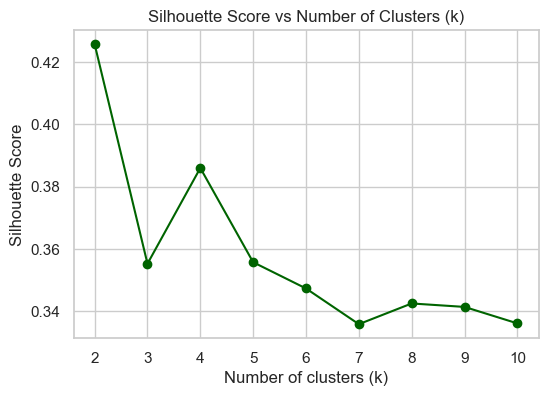

In [39]:
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score 

sil_scores = [] 

# Silhouette cannot be computed for k=1 because a single group has no neighbors!
for k in range(2,11): 
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pokemon_scaled) 
    score = silhouette_score(X_pokemon_scaled, labels) 
    sil_scores.append(score) 

# Erase the chalkboard memory and plot our Silhouette graph
plt.clf() 
plt.figure(figsize=(6,4))
plt.plot(range(2,11), sil_scores, marker = 'o', color="darkgreen") 
plt.title("Silhouette Score vs Number of Clusters (k)")
plt.xlabel("Number of clusters (k)") 
plt.ylabel("Silhouette Score") 
plt.show()

"To evaluate cluster quality and separation, a Silhouette Analysis was performed for $k$ values from 2 to 10. The silhouette score measures both cluster cohesion and separation, where a higher score indicates better-defined clusters.The plot reveals that the highest overall silhouette score occurs at $k=2$ ($\approx 0.43$). However, a secondary local maximum peak occurs clearly at $k=4$ ($\approx 0.39$). While $k=2$ offers the highest mathematical separation, it provides low granularity for practical interpretation. Because $k=4$ represents a strong local peak and aligns perfectly with the 'elbow' observed in the WCSS graph, $k=4$ is selected as the optimal compromise between mathematical separation and actionable interpretation for the Pokémon stat profiles."

### 4.2) Visualize the clusters.

In [40]:
from sklearn.cluster import KMeans 

# 1. Create the KMeans model with our chosen k = 4
kmeans_pokemon = KMeans(n_clusters=4, random_state=42, n_init=10)

# 2. Fit the model on the SCALED data and get cluster labels
cluster_labels = kmeans_pokemon.fit_predict(X_pokemon_scaled) 

# 3. Save labels back into the original dataframe
pokemon_df["CLuster"] = cluster_labels 

# 4. View the top of the dataframe to confirm it worked
pokemon_df[["Name", "Attack", "Defense", "Cluster"]].head()

C:\Users\tiwa1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


,Name,Attack,Defense,Cluster
0,Bulbasaur,49,49,1
1,Ivysaur,62,63,1
2,Venusaur,82,83,2
3,VenusaurMega Venusaur,100,123,3
4,Charmander,52,43,1


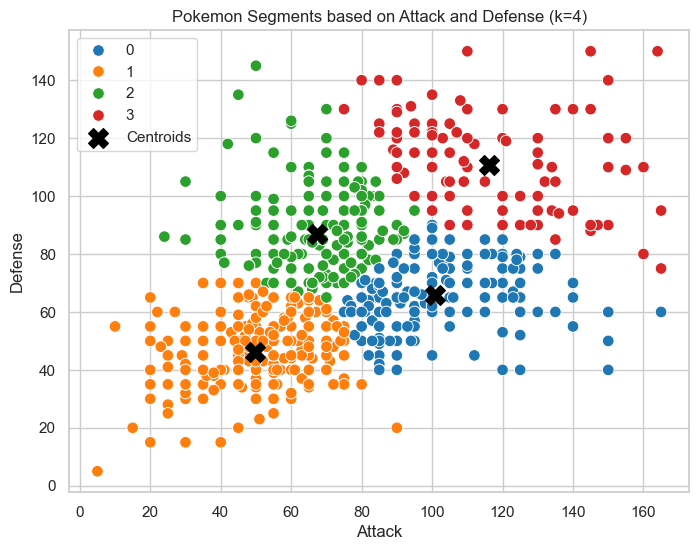

In [41]:
import matplotlib.pyplot as plt 
import seaborn as sns 

# 1. Set up the figure size
plt.figure(figsize=(8,6)) 

# 2. Scatterplot: each point is a Pokémon colored by its cluster
sns.scatterplot( 
    data=pokemon_df, 
    x="Attack", 
    y="Defense", 
    hue="Cluster", 
    palette="tab10",
    s=70
)

# 3. Grab the cluster centers and un-scale them back to regular stat units
centers_scaled = kmeans_pokemon.cluster_centers_ 
centers = scaler.inverse_transform(centers_scaled)

# 4. Plot the cluster centers (Centroids) as big black Xs
plt.scatter( 
    centers[:,0], centers[:,1], 
    s=200,
    c="black",
    marker="X",
    label="Centroids"
)

# 5. Add titles and labels for Pokémon metrics
plt.title("Pokemon Segments based on Attack and Defense (k=4)")
plt.xlabel("Attack") 
plt.ylabel("Defense") 
plt.legend() 
plt.show()

### 4.3) Perform cluster profiling to interpret your finding. Based on profiling, suggesting appropriate actions for each segment.

In [42]:
# Group by the new clusters and calculate the mean for the stats 
pokemon_df.groupby("Cluster")[["Attack", "Defense"]].mean() 

,Attack,Defense
Cluster,,
0,100.899471,65.899471
1,50.166667,46.833333
2,68.109195,88.218391
3,116.625000,111.321429


Looking at the numbers, our Pokémon naturally split into four distinct combat styles. Cluster 3 is the absolute powerhouse group, boasting top-tier scores in both average Attack ($\approx 116.6$) and Defense ($\approx 111.3$), making them perfect for endgame content or legendary tier positioning. Cluster 0 holds the classic 'Glass Cannons' that pack a heavy punch with an average Attack of $100.9$ but have lower durability ($65.9$), meaning they benefit from speed-centric items or high-risk battle moves. Cluster 2 represents the 'Shield Tanks' which reverse that script by leaning heavily into a solid average Defense of $88.2$ despite a lower Attack ($68.1$), carving out a great niche for status-inflicting hazards or stalling tactics. Finally, Cluster 1 captures the baseline 'Starter Squad' with low average marks across the board ($50.2$ Attack, $46.8$ Defense), making them perfect for early-game progression areas where characters still have room to evolve."

## 5) Perform K-Means Clustering using `HP` and `Speed`.

### 5.1) Identify the appropriate number of clusters using the Silhouette score method.  Plotting a line chart of silhouette scores vs the number of clusters.

* *Note: To ensure the results are reproducible, I will use **`random_state=42`** and **`n_init=10`** when applying clustering.*

C:\Users\tiwa1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\tiwa1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\tiwa1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\tiwa1\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Figure size 640x480 with 0 Axes>

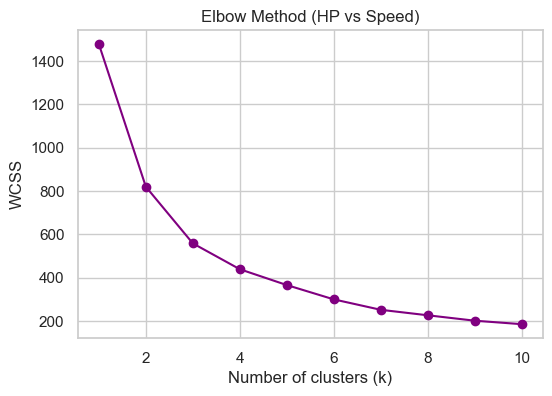

In [71]:
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans 

#1. Grab our new features (HP and Speed) 
X2_pokemon = pokemon_df[["HP", "Speed"]] 
X2_pokemon.head()

#2. Scale our new features 
scaler2 = StandardScaler() 
X2_pokemon_scaled = scaler2.fit_transform(X2_pokemon) 

#3. Use Elbow Method (K = 1 to 10)
wcss2 = [] 

for k in range(1, 11): 
    kmeans2 = KMeans(n_clusters=k, random_state=42, n_init=10) 
    kmeans2.fit(X2_pokemon_scaled) 
    wcss2.append(kmeans2.inertia_)

#4. Plot the Elbow graph 
plt.clf() #Clears any old plots out memory 
plt.figure(figsize=(6,4)) 
plt.plot(range(1,11), wcss2, marker='o', color="purple")
plt.title("Elbow Method (HP vs Speed)") 
plt.xlabel("Number of clusters (k)") 
plt.ylabel("WCSS") 
plt.show()

# **Part B: Supervised Learning – Predicting Total Pokemon Stats**

## 6) Import the data.

In [44]:
import pandas as pd 

# Loading pokemon data while keeping "None" as a real category for Type 2
pokemon_df = pd.read_csv("Downloads/archive (1)/PokemonData.csv", keep_default_na=False) 

pokemon_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Downloads/archive (1)/PokemonData.csv'

Basic overview of the dataset.

In [72]:
pokemon_df.shape

(739, 15)

In [73]:
pokemon_df.dtypes

Num            int64
Name          object
Type1         object
Type2         object
HP             int64
Attack         int64
Defense        int64
SpAtk          int64
SpDef          int64
Speed          int64
Generation     int64
Legendary       bool
Cluster        int32
CLuster        int32
Total          int64
dtype: object

In [74]:
pokemon_df.describe()

,Num,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Cluster,CLuster,Total
count,739.000000,739.000000,739.00000,739.000000,739.000000,739.000000,739.000000,739.000000,739.000000,739.000000,739.000000
mean,363.267930,66.719892,77.43843,71.227334,70.872801,69.307172,67.755074,3.342355,1.282815,1.589986,423.320704
std,209.200229,20.726671,30.67369,26.637581,30.315416,24.368425,28.222276,1.664382,1.009368,1.021958,112.862286
min,1.000000,10.000000,5.00000,5.000000,10.000000,20.000000,10.000000,1.000000,0.000000,0.000000,180.000000
25%,182.500000,50.000000,55.00000,50.000000,48.000000,50.000000,45.000000,2.000000,0.000000,1.000000,325.000000
50%,365.000000,65.000000,75.00000,70.000000,65.000000,66.000000,65.000000,3.000000,1.000000,2.000000,430.000000
75%,542.500000,80.000000,97.50000,89.500000,92.000000,85.000000,90.000000,5.000000,2.000000,2.000000,500.000000
max,721.000000,125.000000,165.00000,150.000000,160.000000,135.000000,150.000000,6.000000,3.000000,3.000000,720.000000


### 6.3) Identify numerical and categorical columns for future use.

## 7) Clean the data.

### 7.1) Remove the duplicate rows (if exist).

* *Note: After removing duplicatest, going to make sure to output the dataset's shape again.*

In [75]:
# Checking how many duplicate rows there are 
pokemon_df.duplicated().sum()

np.int64(0)

In [76]:
pokemon_df = pokemon_df.drop_duplicates()

In [77]:
pokemon_df.shape

(739, 15)

### 7.2) Handle missing values (if exist).

In [78]:
pokemon_df.isna().sum()

Num           0
Name          0
Type1         0
Type2         0
HP            0
Attack        0
Defense       0
SpAtk         0
SpDef         0
Speed         0
Generation    0
Legendary     0
Cluster       0
CLuster       0
Total         0
dtype: int64

### 7.3) Checking the 'Generation' column and see if there is any abnormal value(s).

* *Note: After handling outliers, going to output the dataset's shape again.*

In [79]:
# Convert Generation to numeric just in case there are string errors
pokemon_df["Generation"] = pd.to_numeric(pokemon_df["Generation"], errors="coerce")

# Describe Generation to check min/max 
pokemon_df["Generation"].describe()

count    739.000000
mean       3.342355
std        1.664382
min        1.000000
25%        2.000000
50%        3.000000
75%        5.000000
max        6.000000
Name: Generation, dtype: float64

## 8) Performing deeper exploratory data analysis (EDA).

### Univariate Analysis.

In [80]:
pokemon_df.head()

,Num,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary,Cluster,CLuster,Total
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,1,1,318
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,1,1,405
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,2,3,525
3,3,VenusaurMega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,3,0,625
4,4,Charmander,Fire,Flying,39,52,43,60,50,65,1,False,1,1,309


<Figure size 1200x800 with 0 Axes>

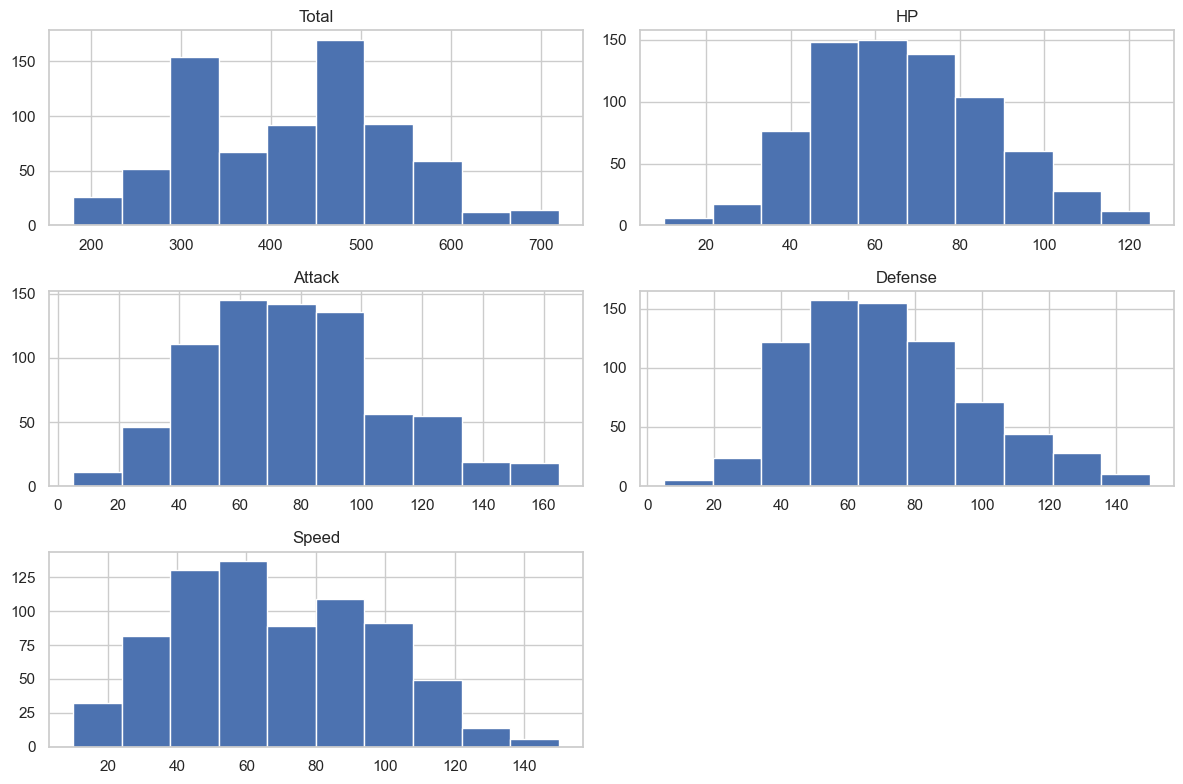

In [81]:
import matplotlib.pyplot as plt 
import seaborn as sns 

# Creating the 'Total' column by summing all base stats
pokemon_df["Total"] = pokemon_df[["HP", "Attack", "Defense", "SpAtk", "SpDef", "Speed"]].sum(axis=1)

# Running numerical analysis safely!
num_cols = ["Total", "HP", "Attack", "Defense", "Speed"]

plt.figure(figsize=(12, 8))
pokemon_df[num_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

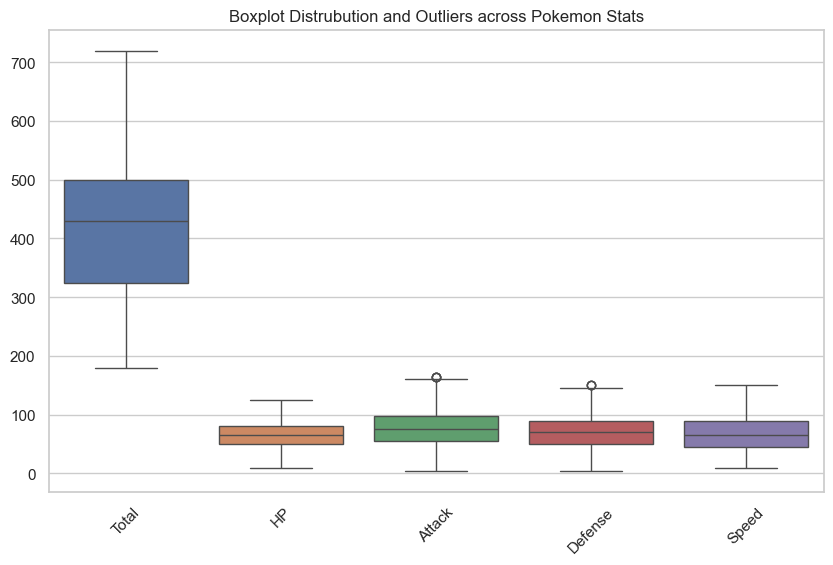

In [82]:
# Boxplots to inspect outliers across all numerical stat columns
plt.figure(figsize=(10,6)) 
sns.boxplot(data=pokemon_df[num_cols]) 
plt.title("Boxplot Distrubution and Outliers across Pokemon Stats")
plt.xticks(rotation=45) 
plt.show()

In [83]:
pokemon_df["Type1"].value_counts()

Type1
Water       102
Normal       92
Grass        70
Bug          65
Fire         51
Psychic      47
Electric     43
Rock         38
Ground       31
Dark         30
Poison       28
Ghost        28
Dragon       26
Fighting     26
Ice          22
Steel        21
Fairy        15
Flying        4
Name: count, dtype: int64

### 8.2) Bivariate Analysis.

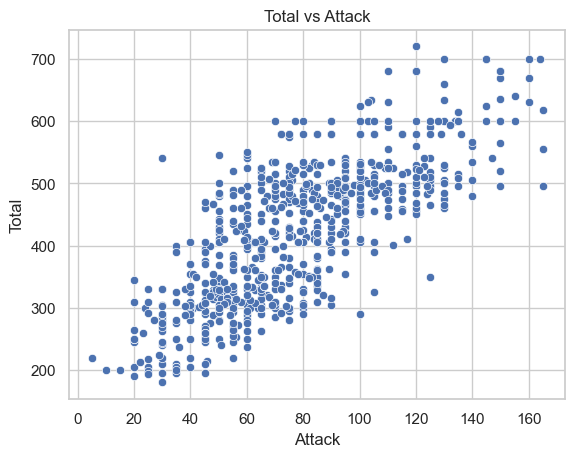

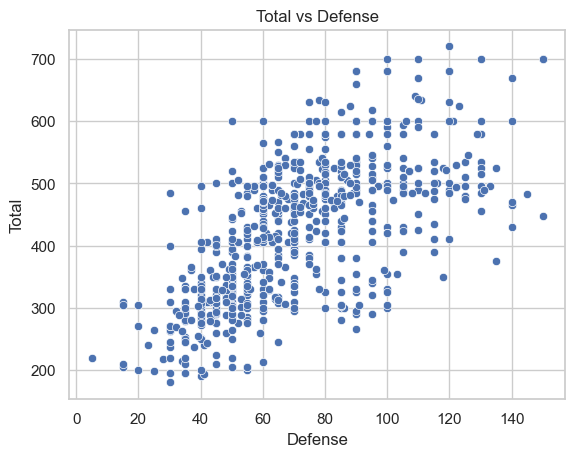

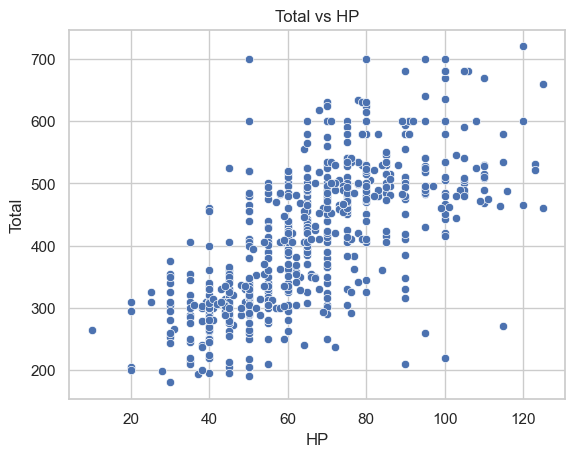

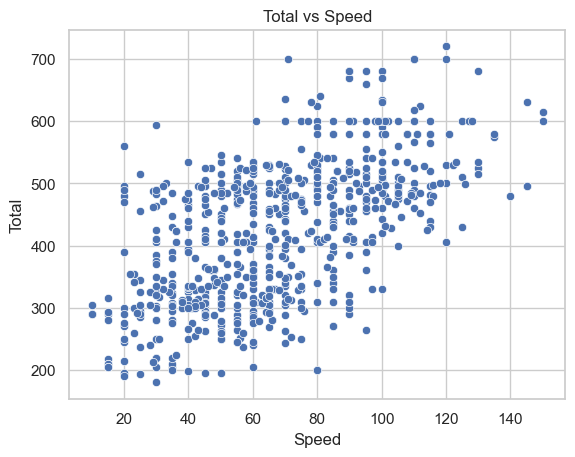

In [84]:
import seaborn as sns 
import matplotlib.pyplot as plt

# 1. Total Value vs Attack
sns.scatterplot(x="Attack", y="Total", data=pokemon_df)
plt.title("Total vs Attack") 
plt.show()

# 2. Total Value vs Defense
sns.scatterplot(x="Defense", y="Total", data=pokemon_df) 
plt.title("Total vs Defense") 
plt.show() 

# 3. Total Value vs HP
sns.scatterplot(x="HP", y="Total", data=pokemon_df) 
plt.title("Total vs HP") 
plt.show() 

# 4. Total Value vs Speed
sns.scatterplot(x="Speed", y="Total", data=pokemon_df) 
plt.title("Total vs Speed") 
plt.show() 

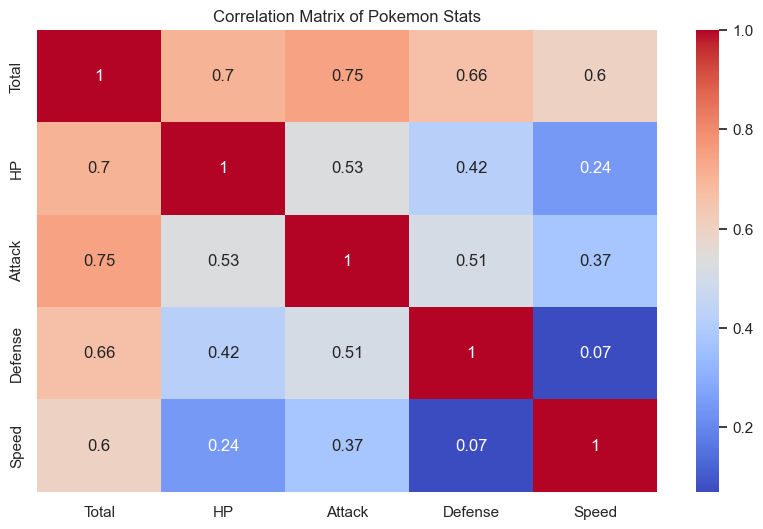

In [85]:
# Calculate the correlation matrix for numerical columns only
corr = pokemon_df[num_cols].corr() 

# Set up the figure dimensions (10 inches wide, 6 inches tall)
plt.figure(figsize=(10,6)) 

# Plot the correlation heatmap with numbers annotated inside
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Pokemon Stats") 
plt.show() 

## 9) Further data preparation for modeling.

### 9.1) Splitting the data into a training (70%) and a testing (30%) datasets.

* *Note: To ensure the results are reproducible, going to use **`random_state=42`** when splitting.*

* *Note: After spliting, going to make sure to output the datasets' shape (rows) again.*

In [86]:
from sklearn.model_selection import train_test_split 

# 1. Define Features (X) and Target (y)
X = pokemon_df[["Type1","Attack", "HP", "Defense", "Speed"]]
y = pokemon_df["Total"] 

# 2. Split into 70% Training and 30% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42 
)

# 3. Output dataset shapes (rows and columns)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:",y_train.shape) 
print("y_test shape:", y_test.shape)

X_train shape: (517, 5)
X_test shape: (222, 5)
y_train shape: (517,)
y_test shape: (222,)


In [87]:
import pandas as pd 
from sklearn.preprocessing import OneHotEncoder 

# 1. Initialize the encoder (drop='first' handles multicollinearity/dummy variable trap)
encoder = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")

# 2. Fit ONLY on X_train and transform both training and testing sets
encoded_train = encoder.fit_transform(X_train[["Type1"]]) 
encoded_test = encoder.transform(X_test[["Type1"]])

# 3. Grab the new feature names (e.g., Type1_Fire, Type1_Water)
encoded_cols = encoder.get_feature_names_out(["Type1"]) 

# 4. Convert the output arrays back into clean DataFrames with matching indexes
train_type_df = pd.DataFrame(encoded_train, columns=encoded_cols, index=X_train.index) 
test_type_df = pd.DataFrame(encoded_test, columns=encoded_cols, index=X_test.index)

# 5. Drop the old text column and append the new 1/0 columns
X_train_encoded = pd.concat([X_train.drop(columns=["Type1"]), train_type_df], axis=1)
X_test_encoded = pd.concat([X_test.drop(columns=["Type1"]), test_type_df], axis=1)

# 6. Verify the new shapes
print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape:", X_test_encoded.shape)

X_train_encoded shape: (517, 21)
X_test_encoded shape: (222, 21)


## 10) Train a Linear Regression model to explain/predict the 'TOTAL stats of Pokemon' using all the available features.

In [88]:
from sklearn.linear_model import LinearRegression 

#1. Initialize the Linear Regression model (creates the blank model)
model = LinearRegression() 

# 2. Train (fit) the model using ONLY the training data
model.fit(X_train_encoded, y_train) 

print("Model training complete!") 

# 3. Generate predictions for the unseen test set
y_pred = model.predict(X_test_encoded) 

# Show the first 5 predicted scores vs actual scores
print("First 5 Predicted Scores:", y_pred[:5].round(1))
print("First 5 Actual Scores:",y_test.iloc[:5].values)

Model training complete!
First 5 Predicted Scores: [424.9 405.6 526.2 461.7 483.3]
First 5 Actual Scores: [410 405 510 428 490]


### 10.1) Before training, we need to define final features (predictors) and target (label).

In [62]:
# Target (Label)
y = pokemon_df["Total"] 

# Features (Predictors) - combined numeric stats and encoded columns
X = X_train_encoded 

### 10.2) Train the Linear Regression model.

In [65]:
from sklearn.linear_model import LinearRegression 

# 1. Initialize the model (creates the empty AI brain)
model = LinearRegression() 

# 2. Train (fit) the model using ONLY the training data splits
model.fit(X_train_encoded, y_train)

print("Model training complete!") 

Model training complete!


### 10.3) Evaluating the performance of the model on both the training and the testing dataset using R-squared.

In [67]:
# 1. Calculate the R-squared score on the Training data
train_r2 = model.score(X_train_encoded, y_train) 

# 2. Calculate the R-squared score on the Testing data
test_r2 = model.score(X_test_encoded, y_test) 

# Print the results neatly
print(f"Training R-squared Score: {train_r2:.4f}") 
print(f"Testing R-squared Score: {test_r2:.4f}")

Training R-squared Score: 0.9188
Testing R-squared Score: 0.9214


In [ ]:
# 1. Calculate the R-squared score on the Training data
train_r2 = model.score(X_train_encoded, y_train)

# 2. Calculate the R-squared score on the Testing data
test_r2 = model.score(X_test_encoded, y_test) 

# Print the results neatly
print(f"Training Score: {train_r2:.4f}")
print(f"Test Score: {test_r2:.4f}")

### 10.4) Interprete the R-squared value for your model.

The Linear Regression model is able to explain approximately 92.1% (or 92.14%) of the variance observed in the target variable (Total), based on the feature predictors (base stats and encoded types).

### 10.5) Provide the interpretation of any three model coefficients.

* *Note:  Presenting the coefficients, making sure to not only output their values but also provide an interpretation of their economic significance.*

In [89]:
import pandas as pd 

# Extract the weights (coefficients) from the trained model
coefficients = model.coef_

# Pair them up with their feature names
feature_names = X_train_encoded.columns
coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coefficients})

print(coef_df)

           Feature  Coefficient
0           Attack     1.029831
1               HP     1.690793
2          Defense     1.523777
3            Speed     1.576216
4       Type1_Dark    10.159898
5     Type1_Dragon    17.763552
6   Type1_Electric    34.259786
7      Type1_Fairy    38.493235
8   Type1_Fighting    -5.362117
9       Type1_Fire    23.719501
10    Type1_Flying    24.485936
11     Type1_Ghost    15.702846
12     Type1_Grass    21.106850
13    Type1_Ground   -19.597288
14       Type1_Ice    29.080253
15    Type1_Normal   -12.240069
16    Type1_Poison    -0.445935
17   Type1_Psychic    46.667553
18      Type1_Rock    -1.606718
19     Type1_Steel     1.837858
20     Type1_Water    17.685029


Type1_Psychic (46.67): Holding all other stats constant, a Pokémon being a Psychic type increases its predicted Total score by 46.67 points. This has a strong positive impact on total stat budget.

Type1_Ground (-19.60): Holding all other stats constant, a Pokémon being a Ground type decreases its predicted Total score by 19.60 points, indicating a negative impact relative to the baseline.

Attack (1.03): Holding all other features constant, every 1-point increase in a Pokémon's Attack stat increases its predicted Total score by 1.03 points.